In [807]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [808]:
path_port_serial = "/dev/ttyUSB1"

In [809]:
#l = serial.Serial()
#l.port=path_port_serial
#l.baudrate = 115200
#l.bytesize = 8
#l.open()
#l.write(bytearray([2]))
#l.close()



In [810]:
import random as rd
import time

In [1117]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:03d}',end=' ')
    print()

In [1121]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*3**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*3**(BitsPorSimbolo))
  return [Ain,Bin]

In [813]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [814]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [815]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [816]:
def send_matrix(X,input,flag,k=0):
  file = open(f"teste{input}.txt","+w")
  size = X.shape[0]
  Y = np.zeros((size,size),dtype=int)
  fs_fpga2pc_rate = 5e+3
  fs_pc2fpga_rate = 15e+3
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop

  s.open()
  s.write(bytearray([255]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([255]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      time.sleep(1/fs_pc2fpga_rate)
  if(k):
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
  else:
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    s.write(bytearray([0xaa]))
    time.sleep(1/fs_pc2fpga_rate)
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    time.sleep(1/fs_fpga2pc_rate)
  
  s.close()  
  s.close()  
  return Y
 

In [817]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[7, 3, 2, 7],
        [6, 3, 3, 5],
        [2, 7, 4, 4],
        [7, 2, 2, 1]]),
 array([[4, 5, 5, 7],
        [1, 5, 1, 3],
        [4, 7, 2, 5],
        [6, 1, 6, 6]])]

In [818]:
M_p = shiftMatrixSystolic(M[0],M[1])

In [819]:
M_p

[array([[0, 0, 0, 7, 3, 2, 7],
        [0, 0, 6, 3, 3, 5, 0],
        [0, 2, 7, 4, 4, 0, 0],
        [7, 2, 2, 1, 0, 0, 0]]),
 array([[0, 0, 0, 4, 1, 4, 6],
        [0, 0, 5, 5, 7, 1, 0],
        [0, 5, 1, 2, 6, 0, 0],
        [7, 3, 5, 6, 0, 0, 0]])]

In [820]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    #M = create_matrix(Din = 16, BitsPorSimbolo=np.log2(1))
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=0)
    #rec_matrix(4)
    #rec_matrix(M[0].shape[0])
    print(M[0]@M[1])
    print(0)
#    time.sleep(10)


Matriz ----------------------- 0 --------------------------
[[ 81  71  84 110]
 [ 69  71  69  96]
 [ 55  77  49  79]
 [ 44  60  47  71]]
0


## Representação do problema 
         OPA   OPB
 ....f000776af000776a_f000776a0f00776....
 ....f001370af001370a_f001370a0f01370....
 ....f031100af031100a_f031100a0f31100....
 ....f193000af193000a_f193000a1f93000....



In [821]:
def send_matrix_rec(X,input,flag,k=0):
  file = open(f"teste{input}.txt","+w")
  fs_pc2fpga_rate = 15e+3
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  size  = X.shape[0]
  s.open()
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      if(flag):
        s.write(bytearray([X[j][i]]))
      else:
        s.write(bytearray([0]))
      time.sleep(1/fs_pc2fpga_rate)

  s.write(bytearray([0xaa]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xaa]))
  time.sleep(1/fs_pc2fpga_rate)
  #if(k):
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    print(s.read()[0])
    #    #time.sleep(1/(fs_fpga2pc_rate))
    #s.close()
    #while(True):
    #  print(s.read()[0])  
    #  time.sleep(1/(fs_fpga2pc_rate))
  s.close()  

 

In [1122]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[1, 3, 1, 1],
        [3, 1, 1, 3],
        [1, 2, 2, 2],
        [3, 3, 3, 1]]),
 array([[1, 2, 1, 3],
        [3, 3, 1, 1],
        [3, 2, 3, 2],
        [2, 2, 1, 2]])]

In [823]:
M[0].shape[1]

4

In [824]:
M[0].shape[0]

4

In [825]:
def transmitter_uart(M):
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix_rec(M_p[0],"INPUT_A1",1,k=0)
    send_matrix_rec(M_p[1],"INPUT_B1",1,k=1)

In [1318]:
def receiver_uart(size):
    fpga2pc_rate = 10472
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = 115200
    s.bytesize = 8
    s.open()
    Y= np.zeros((size,size),dtype=int)
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    while(True):
        a = s.read()[0]
        if(a!=0 and a!=254):
            i+=1
            Y[index_row][index_col] = a
            #print(a,index_row,index_col)
            index_row +=1
            if(index_col == size):
                index_row +=1
                if(index_col == size-1 and index_row == size-1):
                    flag = 1
                    break
                index_row = 0
            if(i == size**2 or flag ):
                break


        #if(a==0):
        #    break
    return Y

In [1320]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    M = create_matrix(Din =4, BitsPorSimbolo=np.log2(2))

    transmitter_uart(M)
    #time.sleep(1)
    Y = receiver_uart(M[0].shape[0])
    print("Alvo: \n")
    print_matrix(M[0]@M[1])
    print("Obtido: \n")
    print_matrix(Y)
    
    #time.sleep(3)# 10.472kHz


Matriz ----------------------- 0 --------------------------
Alvo: 

013 010 009 020 
020 013 014 028 
011 006 007 014 
016 010 013 021 
Obtido: 

013 020 011 016 
010 013 006 010 
009 014 007 013 
020 028 014 021 


In [1263]:
Y

array([[117,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0]])

In [865]:
a = b'\x11'
int(hex(int(a[0]))[2:])


11

In [868]:
for i in range(2):
    print("Matriz -----------------------",i,"--------------------------")
    #M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M[0]@M[1])
    send_matrix(M_p[0],"INPUT_A1",1,k=1)
    send_matrix(M_p[1],"INPUT_B1",1,k=0)
    
    #time.sleep(10)


Matriz ----------------------- 0 --------------------------
[[ 93  58  60  47]
 [139  84  66  59]
 [ 91  56  64  51]
 [115  76  54  43]]
Matriz ----------------------- 1 --------------------------
[[ 93  58  60  47]
 [139  84  66  59]
 [ 91  56  64  51]
 [115  76  54  43]]


In [867]:
M[0]

array([[3, 6, 2, 6],
       [7, 4, 6, 6],
       [3, 6, 4, 4],
       [7, 4, 2, 6]])

In [832]:
M[1]

array([[2, 4, 6, 7],
       [1, 4, 6, 5],
       [7, 4, 2, 1],
       [7, 7, 4, 4]])

In [833]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [834]:
M[1]@M[0]

array([[85, 87, 89, 69],
       [67, 71, 77, 56],
       [55, 35, 49, 38],
       [92, 69, 89, 64]])

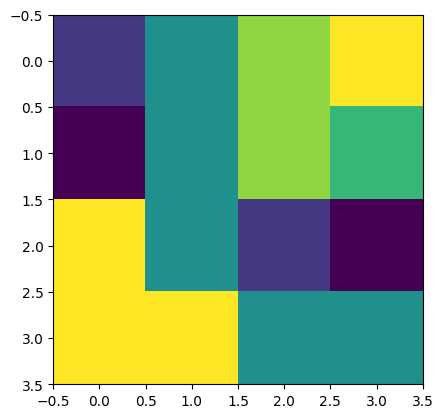

In [835]:
plt.imshow(M[1])

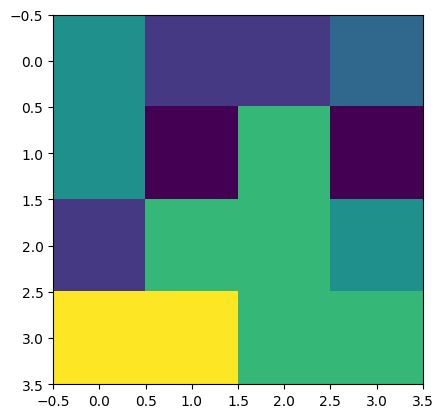

In [836]:
plt.imshow(M[0])

In [837]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [838]:
M[1]@M[0]

array([[85, 87, 89, 69],
       [67, 71, 77, 56],
       [55, 35, 49, 38],
       [92, 69, 89, 64]])

In [839]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [840]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 4, 2, 2, 3],
        [0, 0, 4, 1, 5, 1, 0],
        [0, 2, 5, 5, 4, 0, 0],
        [7, 7, 5, 5, 0, 0, 0]]),
 array([[0, 0, 0, 4, 4, 2, 7],
        [0, 0, 2, 1, 5, 7, 0],
        [0, 2, 5, 5, 5, 0, 0],
        [3, 1, 4, 5, 0, 0, 0]]))

In [841]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [842]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [843]:
M

[array([[4, 2, 2, 3],
        [4, 1, 5, 1],
        [2, 5, 5, 4],
        [7, 7, 5, 5]]),
 array([[2, 4, 6, 7],
        [1, 4, 6, 5],
        [7, 4, 2, 1],
        [7, 7, 4, 4]])]

In [844]:
M_p[0]

array([[0, 0, 0, 4, 2, 2, 3],
       [0, 0, 4, 1, 5, 1, 0],
       [0, 2, 5, 5, 4, 0, 0],
       [7, 7, 5, 5, 0, 0, 0]])

In [845]:
M_p[1]

array([[0, 0, 0, 4, 4, 2, 7],
       [0, 0, 2, 1, 5, 7, 0],
       [0, 2, 5, 5, 5, 0, 0],
       [3, 1, 4, 5, 0, 0, 0]])

In [846]:
def send_matrix1(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()
  file.write(f'{0XAA:02X}'+"\n")
  file.write(f'{0XAA:02X}'+"\n")
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix1(M_p[0],"INPUT_A1",0)
    send_matrix1(M_p[1],"INPUT_B1",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [847]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

0 0 0 004 002 002 003 
0 0 004 001 005 001 0 
0 002 005 005 004 0 0 
007 007 005 005 0 0 0 


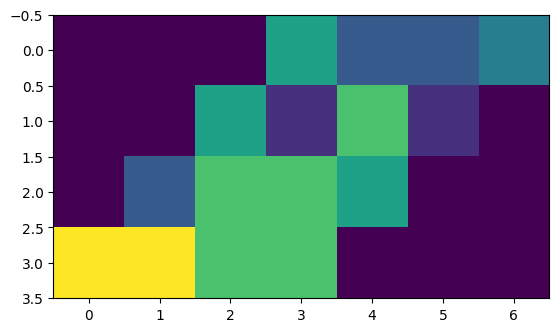

In [848]:
print_matrix(M_p[0])
plt.imshow(M_p[0])

In [849]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [850]:
M_p[1]

array([[0, 0, 0, 2, 1, 7, 7],
       [0, 0, 4, 4, 4, 7, 0],
       [0, 6, 6, 2, 4, 0, 0],
       [7, 5, 1, 4, 0, 0, 0]])

In [851]:
M_p[0]

array([[0, 0, 0, 4, 2, 2, 3],
       [0, 0, 4, 1, 5, 1, 0],
       [0, 2, 5, 5, 4, 0, 0],
       [7, 7, 5, 5, 0, 0, 0]])

In [852]:
print_matrix(M[0]@M[1])

045 053 052 052 
051 047 044 042 
072 076 068 060 
091 111 114 109 


In [853]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [854]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 4, 2, 2, 3],
        [0, 0, 4, 1, 5, 1, 0],
        [0, 2, 5, 5, 4, 0, 0],
        [7, 7, 5, 5, 0, 0, 0]]),
 array([[0, 0, 0, 2, 1, 7, 7],
        [0, 0, 4, 4, 4, 7, 0],
        [0, 6, 6, 2, 4, 0, 0],
        [7, 5, 1, 4, 0, 0, 0]])]

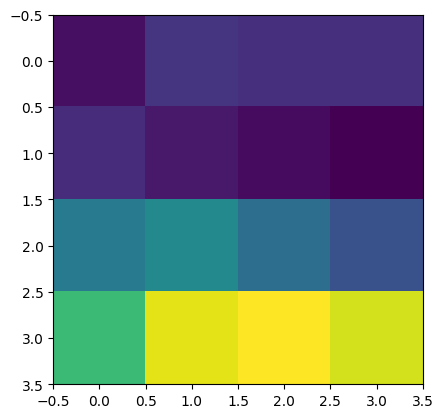

In [855]:
plt.imshow(M[0]@M[1])

plt.show()

In [856]:

#for i in range(100):
#    print("----------------------",i,"--------------------------")
#    M_p = shiftMatrixSystolic(M[0],M[1])
#    #Bin = M[1]
#    send_matrix(M_p[0],"INPUT_A1",0)
#    send_matrix(M_p[1],"INPUT_B1",0)
#    
#    break
#    time.sleep(10)
#
#send_matrix(Bin)

In [857]:
M[0]

array([[4, 2, 2, 3],
       [4, 1, 5, 1],
       [2, 5, 5, 4],
       [7, 7, 5, 5]])

In [858]:
M[1]

array([[2, 4, 6, 7],
       [1, 4, 6, 5],
       [7, 4, 2, 1],
       [7, 7, 4, 4]])

In [859]:
M[0]@M[1]

array([[ 45,  53,  52,  52],
       [ 51,  47,  44,  42],
       [ 72,  76,  68,  60],
       [ 91, 111, 114, 109]])

In [860]:
s = serial.Serial()

s.port = path_port_serial
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [861]:
i =1
s.write(bytearray([int(i)]))


1

In [862]:
serial.Serial()

Serial<id=0x7fa793ec0a60, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)